---
title: Convert CfRadial1 NetCDF to CfRadial2 Zarr with xradar
author: Chia-Wei Hsu
date: "2026-10-08"
---

# Access S-Pol PRECIP Radar Data through the NCAR GDEX and Convert CfRadial1 to CfRadial2

:::{important} Important Info for the Data
The example file is a single **RHI (Range Height Indicator)** volume from the NCAR/EOL **S-Pol** S-band dual-polarization radar,
deployed in northern Taiwan during the 2022 PRECIP (Prediction of Rainfall Extremes Campaign In the Pacific) field campaign.

The file is stored in the **CfRadial1** format, a single flat NetCDF file in which all sweeps are concatenated along the `time` (ray) dimension.
This particular file also uses the *ragged* gate layout (`n_gates_vary = "true"`): every field is stored as a 1-D `n_points` array, and
`ray_start_index` / `ray_n_gates` describe where each ray starts and how many gates it has.
:::

## Required Packages
The following packages are needed for this example. Please make sure they are installed before moving forward.
- `xarray`
- `xradar`
- `h5netcdf>=1.8.0`
- `netCDF4`
- `zarr`
- `numpy`
- `matplotlib`
- `cmweather`

:::{important} Important Info for the Packages
- `xradar` registers the `.xradar` accessor on `xarray.Dataset` and `xarray.DataTree` **only after it is imported**.
  Calling `ds.xradar...` without `import xradar` raises `AttributeError: 'Dataset' object has no attribute 'xradar'`.
- Recent `xarray` releases require `h5netcdf>=1.8.0`. With an older `h5netcdf`, `xr.open_dataset(..., engine="h5netcdf")`
  fails with `AttributeError: 'Variable' object has no attribute 'filters'`.
:::

## Why CfRadial1 to CfRadial2
Radar data are often distributed in the **CfRadial1** format: one flat NetCDF file per volume, where all sweeps are stacked along the ray (`time`) dimension.
The newer **CfRadial2** data model (based on the WMO FM 301 standard) stores each sweep in its own group, together with dedicated groups for radar parameters, calibration and georeferencing. That hierarchical structure maps naturally onto an `xarray.DataTree`, and onto cloud-optimized formats such as **Zarr**.

In this notebook we will:
1. Open a CfRadial1 NetCDF file from GDEX.
2. Convert it to a CfRadial2 `DataTree` with xradar's `.xradar.to_cf2()` method
   (see the xradar [Transform](https://docs.openradarscience.org/projects/xradar/en/stable/notebooks/Transform.html) notebook).
3. Write the CfRadial2 `DataTree` to a local **Zarr** store and to a **NetCDF4** file.
4. Do a round trip, CfRadial2 → CfRadial1, and check that the radar data are unchanged compared with the original NetCDF file
   (see the xradar [CfRadial1 to CfRadial2 Data Model Transformation](https://docs.openradarscience.org/projects/xradar/en/stable/notebooks/CfRadial1_Model_Transformation.html) notebook).

## 1. Open CfRadial1
The example file is available on GDEX both through the GDEX POSIX path (on NCAR HPC systems such as Derecho/Casper) and through an HTTPS data URL.
In this example we use the **GDEX POSIX path**. If you are not on an NCAR system, set `use_posix = False` to read the same file over HTTPS.

In [2]:
# Please specify your preferred data access method: the Data URL or the GDEX POSIX path.
# filename = "cfrad.20220525_021216.343_to_20220525_021248.129_SPOL_PrecipRhi1_RHI.nc"
filename = "cfrad.20220525_015443.665_to_20220525_015709.985_SPOL_PrecipRhi2_RHI.nc"
data_url = f"https://data.gdex.ucar.edu/special_projects/ard_radar/tutorial/{filename}"
data_posix_path = f"/gdex/data/special_projects/ard_radar/tutorial/{filename}"

# True on NCAR HPC (POSIX access), False to stream the file over HTTPS
use_posix = True

We open the CfRadial1 file as a plain `xarray.Dataset`. Note that `import xradar` is required to make the `.xradar` accessor available.

In [3]:
import numpy as np
import xarray as xr
import xradar as xd

if use_posix:
    source = data_posix_path
else:
    source = data_url

ds_cf1 = xr.open_dataset(source, engine="h5netcdf")
ds_cf1

<xarray.Dataset> Size: 596MB
Dimensions:                           (sweep: 11, r_calib: 1, time: 2866,
                                       n_points: 5729134, frequency: 1,
                                       range: 1999)
Coordinates:
  * time                              (time) datetime64[ns] 23kB 2022-05-25T0...
    azimuth                           (time) float32 11kB ...
    elevation                         (time) float32 11kB ...
  * frequency                         (frequency) float32 4B 2.81e+09
  * range                             (range) float32 8kB 75.0 ... 2.998e+05
Dimensions without coordinates: sweep, r_calib, n_points
Data variables: (12/124)
    volume_number                     float64 8B ...
    platform_type                     |S32 32B ...
    primary_axis                      |S32 32B ...
    status_xml                        |S10082 10kB ...
    instrument_type                   |S32 32B ...
    radar_antenna_gain_h              float32 4B ...
    ...                                ...
    SNRVC_F                           (n_points) float32 23MB ...
    DBMHC                             (n_points) float32 23MB ...
    DBMHC_F                           (n_points) float32 23MB ...
    DBMVC                             (n_points) float32 23MB ...
    DBMVC_F                           (n_points) float32 23MB ...
    CMD_FLAG                          (n_points) float32 23MB ...
Attributes: (12/25)
    Conventions:          CF-1.7
    Sub_conventions:      CF-Radial instrument_parameters radar_parameters ra...
    version:              CF-Radial-1.4
    title:                
    institution:          
    references:           
    ...                   ...
    site_name:            Nanliao
    scan_name:            PrecipRhi2
    scan_id:              0
    platform_is_mobile:   false
    n_gates_vary:         true
    ray_times_increase:   true

The CfRadial1 file is flat: all sweeps share the `time` dimension, and because `n_gates_vary = "true"` the radar moments (e.g. `DBZ`) are 1-D arrays along `n_points`.

In [4]:
print("n_gates_vary :", ds_cf1.attrs.get("n_gates_vary"))
print("sweeps       :", ds_cf1.sizes["sweep"])
print("rays (time)  :", ds_cf1.sizes["time"])
print("n_points     :", ds_cf1.sizes["n_points"])
print("DBZ dims     :", ds_cf1["DBZ"].dims)

n_gates_vary : true
sweeps       : 11
rays (time)  : 2866
n_points     : 5729134
DBZ dims     : ('n_points',)


## 2. Convert CfRadial1 to CfRadial2
The `.xradar.to_cf2()` method (an alias of `.xradar.to_cfradial2()` / `.xradar.to_cfradial2_datatree()`) converts the flat CfRadial1 `Dataset`
into a CfRadial2 `DataTree`, following the xradar [Transform](https://docs.openradarscience.org/projects/xradar/en/stable/notebooks/Transform.html) notebook.
The ragged `n_points` fields are unpacked onto a regular `(azimuth, range)` grid per sweep, with `NaN` padding where a ray has fewer gates.

The method returns a new object; it does not modify `ds_cf1` in place.

In [5]:
dtree = ds_cf1.xradar.to_cf2()
dtree

<xarray.DataTree 'root'>
Group: /
│   Dimensions:              (sweep: 11, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 2.81e+09
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        float64 8B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S10082 10kB ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       altitude_agl         float64 8B ...
│       sweep_group_name     (sweep) <U10 440B 'sweep_0.0' ... 'sweep_10.0'
│       sweep_fixed_angle    (sweep) float32 44B ...
│   Attributes: (12/14)
│       Conventions:         CF-1.7
│       version:             CF-Radial-1.4
│       title:               
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       instrument_name:     SPOL
│       site_name:           Nanliao
│       scan_name:           PrecipRhi2
│       scan_id:             0
│       platform_is_mobile:  false
│       ray_times_increase:  true
├── Group: /radar_parameters
│       Dimensions:                   ()
│       Data variables:
│           radar_beam_width_h        float32 4B ...
│           radar_beam_width_v        float32 4B ...
│           radar_antenna_gain_h      float32 4B ...
│           radar_antenna_gain_v      float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
├── Group: /radar_calibration
│       Dimensions:                   ()
│       Data variables: (12/55)
│           time                      |S32 32B ...
│           pulse_width               float32 4B ...
│           xmit_power_h              float32 4B ...
│           xmit_power_v              float32 4B ...
│           two_way_waveguide_loss_h  float32 4B ...
│           two_way_waveguide_loss_v  float32 4B ...
│           ...                        ...
│           zdr_correction            float32 4B ...
│           ldr_correction_h          float32 4B ...
│           ldr_correction_v          float32 4B ...
│           system_phidp              float32 4B ...
│           test_power_h              float32 4B ...
│           test_power_v              float32 4B ...
├── Group: /georeferencing_correction
├── Group: /sweep_0
│       Dimensions:                    (elevation: 252, range: 1999)
│       Coordinates:
│         * elevation                  (elevation) float32 1kB -0.5 -0.25 ... 62.0 62.25
│           time                       (elevation) datetime64[ns] 2kB 2022-05-25T01:5...
│           azimuth                    (elevation) float32 1kB ...
│         * range                      (range) float32 8kB 75.0 225.0 ... 2.998e+05
│       Data variables: (12/46)
│           sweep_number               float64 8B ...
│           sweep_mode                 <U3 12B 'rhi'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           ray_n_gates                (elevation) float64 2kB ...
│           ...                         ...
│           RHOHV_NNC_F                (elevation, range) float32 2MB 0.7905 ... 0.2087
│           NCP                        (elevation, range) float32 2MB 0.9965 ... 0.03172
│           TEMP_FOR_PID               (elevation, range) float32 2MB 21.95 ... -74.87
│           PID                        (elevation, range) float32 2MB 17.0 0.0 ... 13.0
│           KDP_F                      (elevation, range) float32 2MB -4.395e-05 ... ...
│           RHOHV_F                    (elevation, range) float32 2MB 0.7905 ... 0.286
├── Group: /sweep_1
│       Dimensions:                    (elevation: 259, range: 1999)
│       Coordinates:
│         * elevation                

In [ ]:
# Check the CfRadial2 hierarchy: root metadata, metadata subgroups and one group per sweep
for node in dtree.subtree:
    print(f"{node.path:25s} dims={dict(node.dataset.sizes)}")

/                         dims={'sweep': 11, 'frequency': 1}
/radar_parameters         dims={'frequency': 1}
/radar_calibration        dims={'frequency': 1}
/georeferencing_correction dims={'frequency': 1}
/sweep_0                  dims={'elevation': 252, 'range': 1999, 'frequency': 1}
/sweep_1                  dims={'elevation': 259, 'range': 1999, 'frequency': 1}
/sweep_2                  dims={'elevation': 259, 'range': 1999, 'frequency': 1}
/sweep_3                  dims={'elevation': 255, 'range': 1999, 'frequency': 1}
/sweep_4                  dims={'elevation': 256, 'range': 1999, 'frequency': 1}
/sweep_5                  dims={'elevation': 260, 'range': 1999, 'frequency': 1}
/sweep_6                  dims={'elevation': 266, 'range': 1999, 'frequency': 1}
/sweep_7                  dims={'elevation': 265, 'range': 1999, 'frequency': 1}
/sweep_8                  dims={'elevation': 266, 'range': 1999, 'frequency': 1}
/sweep_9                  dims={'elevation': 265, 'range': 1999, 

:::{tip} Some Useful Tips
- If you only need the CfRadial2 tree, you can skip the intermediate `Dataset` and read the file directly with
  `xd.io.open_cfradial1_datatree(data_posix_path)`.
- Each sweep group is a regular `xarray.Dataset`, so all the usual xarray selection and plotting tools work, e.g. `dtree["sweep_0"].ds`.
:::

### A quick look at the data
Before writing anything out, we plot the reflectivity of the first RHI sweep. `georeference()` adds Cartesian `x`, `y`, `z` coordinates
(in meters, relative to the radar), and for an RHI we plot height against the horizontal distance from the radar.

In [ ]:
import cmweather  # registers radar colormaps such as "ChaseSpectral"
import matplotlib.pyplot as plt
ds = dtree["sweep_0"].to_dataset()
# bring in the radar location information as coordinates to the Dataset object for the georeferencing
ds['longitude']=dtree["longitude"].values
ds['latitude']=dtree["latitude"].values
ds['altitude']=dtree['altitude'].values
ds = ds.set_coords(["longitude", "latitude", "altitude"])



Text(0.5, 1.0, 'S-Pol RHI reflectivity, fixed azimuth 90.0°')

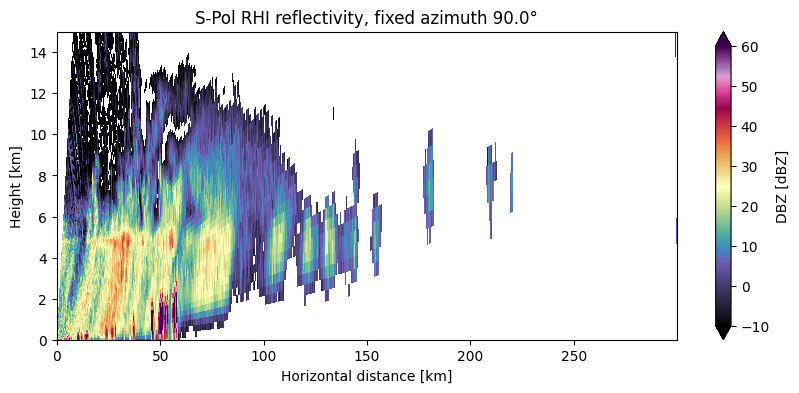

In [ ]:
sweep = ds.xradar.georeference()
horizontal_distance = np.sqrt(sweep["x"] ** 2 + sweep["y"] ** 2) / 1000.0 # in kilometers
sweep = sweep.assign_coords(
    horizontal_distance=horizontal_distance.assign_attrs(long_name="Horizontal distance", units="km"),
    height=(sweep["z"] / 1000.0).assign_attrs(long_name="Height", units="km"),
)

fig, ax = plt.subplots(figsize=(10, 4))
sweep["DBZ"].plot(
    ax=ax,
    x="horizontal_distance",
    y="height",
    cmap="ChaseSpectral",
    vmin=-10,
    vmax=60,
)
ax.set_ylim(0, 15)
ax.set_title(f"S-Pol RHI reflectivity, fixed azimuth {float(sweep.sweep_fixed_angle):.1f}°")

## Write the CfRadial2 DataTree to a local Zarr store
Some variables decoded from the CfRadial1 character arrays (e.g. `time_coverage_start`, `instrument_name`) are **fixed-length string** arrays.
These are not reliably supported by Zarr, so we convert them to variable-length (`object`) strings before writing.
Only the string variables are copied; all other arrays are shared by reference.

In [75]:
from pathlib import Path

output_dir = Path("cf1_to_cf2_tutorial")
output_dir.mkdir(exist_ok=True)

zarr_path = output_dir / filename.replace(".nc", "_cfradial2.zarr")
nc4_path = output_dir / filename.replace(".nc", "_cfradial2.nc")


def fix_string_encoding(ds):
    """Convert fixed-length string variables to object dtype for Zarr compatibility."""
    string_vars = {}
    for var in ds.variables:
        if ds[var].dtype.kind in ("U", "S"):
            string_vars[var] = ds[var].astype(str).astype(object)
    if not string_vars:
        return ds
    return ds.assign(string_vars)


def exact_time_encoding(tree):
    """Encode each sweep's ``time`` as int64 nanoseconds so it round-trips exactly.

    The default float64 "seconds since ..." encoding can shift a few timestamps
    by ~1 ns after a write/read cycle.
    """
    encoding = {}
    for node in tree.subtree:
        if "time" not in node.variables:
            continue
        # Skip groups whose `time` is not a datetime (some metadata groups store it as a string)
        if node["time"].dtype.kind != "M":
            continue
        reference = str(node["time"].values.min().astype("datetime64[s]"))
        encoding[node.path] = {
            "time": {
                "units": f"nanoseconds since {reference}",
                "calendar": "gregorian",
                "dtype": "int64",
            }
        }
    return encoding

In [76]:
%%time
# Apply the string encoding fix to the entire dataset tree and save it as a Zarr store
dtree_for_zarr = dtree.map_over_datasets(fix_string_encoding)
# Save the fixed dataset tree as a Zarr store
# Store time as exact int64 nanoseconds (see exact_time_encoding above)
dtree_for_zarr.to_zarr(
    zarr_path,
    mode="w",
    encoding=exact_time_encoding(dtree_for_zarr),
)

/glade/u/home/chiaweih/test_xradar/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/glade/u/home/chiaweih/test_xradar/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/glade/u/home/chiaweih/test_xradar/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/glade/u/home/chiaweih/test_xradar/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUs

CPU times: user 7.91 s, sys: 2.16 s, total: 10.1 s
Wall time: 10.2 s


/glade/u/home/chiaweih/test_xradar/.venv/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Reopen the Zarr store lazily as a `DataTree`. The groups are the same CfRadial2 groups we wrote.

In [77]:
dtree_zarr = xr.open_datatree(zarr_path, engine="zarr")
dtree_zarr

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 11, frequency: 1)
│   Coordinates:
│     * frequency            (frequency) float32 4B 2.81e+09
│       altitude             float64 8B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│   Dimensions without coordinates: sweep
│   Data variables:
│       altitude_agl         float64 8B ...
│       instrument_type      StringDType() 16B ...
│       platform_type        StringDType() 16B ...
│       primary_axis         StringDType() 16B ...
│       status_str           StringDType() 16B ...
│       sweep_fixed_angle    (sweep) float32 44B ...
│       sweep_group_name     (sweep) StringDType() 176B ...
│       time_coverage_end    StringDType() 16B ...
│       time_coverage_start  StringDType() 16B ...
│       volume_number        float64 8B ...
│   Attributes: (12/14)
│       Conventions:         CF-1.7
│       version:             CF-Radial-1.4
│       title:               
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       instrument_name:     SPOL
│       site_name:           Nanliao
│       scan_name:           PrecipRhi2
│       scan_id:             0
│       platform_is_mobile:  false
│       ray_times_increase:  true
├── Group: /georeferencing_correction
├── Group: /radar_calibration
│       Dimensions:                   ()
│       Data variables: (12/55)
│           antenna_gain_h            float32 4B ...
│           antenna_gain_v            float32 4B ...
│           base_1km_hc               float32 4B ...
│           base_1km_hx               float32 4B ...
│           base_1km_vc               float32 4B ...
│           base_1km_vx               float32 4B ...
│           ...                        ...
│           two_way_radome_loss_v     float32 4B ...
│           two_way_waveguide_loss_h  float32 4B ...
│           two_way_waveguide_loss_v  float32 4B ...
│           xmit_power_h              float32 4B ...
│           xmit_power_v              float32 4B ...
│           zdr_correction            float32 4B ...
├── Group: /radar_parameters
│       Dimensions:                   ()
│       Data variables:
│           radar_antenna_gain_h      float32 4B ...
│           radar_antenna_gain_v      float32 4B ...
│           radar_beam_width_h        float32 4B ...
│           radar_beam_width_v        float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
├── Group: /sweep_0
│       Dimensions:                    (elevation: 252, range: 1999)
│       Coordinates:
│         * elevation                  (elevation) float32 1kB -0.5 -0.25 ... 62.0 62.25
│           azimuth                    (elevation) float32 1kB ...
│           time                       (elevation) datetime64[ns] 2kB ...
│         * range                      (range) float32 8kB 75.0 225.0 ... 2.998e+05
│       Data variables: (12/46)
│           antenna_transition         (elevation) float32 1kB ...
│           CMD_FLAG                   (elevation, range) float32 2MB ...
│           DBMHC                      (elevation, range) float32 2MB ...
│           DBMHC_F                    (elevation, range) float32 2MB ...
│           DBMVC                      (elevation, range) float32 2MB ...
│           DBMVC_F                    (elevation, range) float32 2MB ...
│           ...                         ...
│           unambiguous_range          (elevation) float32 1kB ...
│           VEL                        (elevation, range) float32 2MB ...
│           VEL_F                      (elevation, range) float32 2MB ...
│           WIDTH                      (elevation, range) float32 2MB ...
│           WIDTH_F                    (elevation, range) float32 2MB ...
│           ZDR_F                      (elevation, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (elevation: 259, range: 1999)
│       Coordinates:
│        

## Write the same CfRadial2 DataTree to NetCDF4
The CfRadial2 model is not tied to Zarr. The same `DataTree` can be written to a grouped **NetCDF4** file with xradar's
`xd.io.to_cfradial2()` exporter (or directly with `dtree.to_netcdf()`).

:::{important} Use the `h5netcdf` engine to write
Write this `DataTree` with `engine="h5netcdf"`. The `netcdf4` engine does not work here: it fails with
`RuntimeError: NetCDF: HDF error` and leaves a truncated, still-open file behind. If that happens, restart the kernel
and delete the partial file before writing again.
:::

In [78]:
%%time
# The h5netcdf engine is required to write this DataTree to NetCDF4.
# engine="netcdf4" fails with "RuntimeError: NetCDF: HDF error".
# Use the same exact time encoding as the Zarr store so the two outputs match
dtree_zarr.to_netcdf(
    nc4_path,
    engine="h5netcdf",
    encoding=exact_time_encoding(dtree_zarr),
)
# xd.io.to_cfradial2(dtree, nc4_path, engine="h5netcdf")

CPU times: user 2.53 s, sys: 398 ms, total: 2.93 s
Wall time: 2.5 s


In [79]:
# read the NetCDF4 file into a DataTree
dtree_nc4 = xr.open_datatree(nc4_path, engine="h5netcdf")

In [80]:
# Both stores should hold the same groups and the same radar data
print("Same group structure:", dtree_zarr.isomorphic(dtree_nc4))
for key in list(dtree_zarr.keys()):
    ds_zarr = dtree_zarr[key].to_dataset()
    ds_nc4 = dtree_nc4[key].to_dataset()
    same_data = ds_zarr.equals(ds_nc4)
    print(f"{key:25s} data equal: {same_data}")

Same group structure: True
altitude_agl              data equal: True
instrument_type           data equal: True
platform_type             data equal: True
primary_axis              data equal: True
status_str                data equal: True
sweep_fixed_angle         data equal: True
sweep_group_name          data equal: True
time_coverage_end         data equal: True
time_coverage_start       data equal: True
volume_number             data equal: True
georeferencing_correction data equal: True
radar_calibration         data equal: True
radar_parameters          data equal: True
sweep_0                   data equal: True
sweep_1                   data equal: True
sweep_10                  data equal: True
sweep_2                   data equal: True
sweep_3                   data equal: True
sweep_4                   data equal: True
sweep_5                   data equal: True
sweep_6                   data equal: True
sweep_7                   data equal: True
sweep_8                   d

In [81]:
# Size on disk of the original CfRadial1 file and the two CfRadial2 outputs
def size_mb(path):
    path = Path(path)
    if path.is_dir():
        total = 0
        for file in path.rglob("*"):
            if file.is_file():
                total += file.stat().st_size
        return total / 1e6
    return path.stat().st_size / 1e6


if use_posix:
    print(f"CfRadial1 NetCDF : {size_mb(data_posix_path):7.2f} MB")
print(f"CfRadial2 Zarr   : {size_mb(zarr_path):7.2f} MB")
print(f"CfRadial2 NetCDF4: {size_mb(nc4_path):7.2f} MB")

CfRadial1 NetCDF :   65.17 MB
CfRadial2 Zarr   :   62.26 MB
CfRadial2 NetCDF4:  597.48 MB


## Round trip: CfRadial2 → CfRadial1, compared with the original file
To check that nothing is lost, we convert the CfRadial2 tree **read back from the Zarr store** into a CfRadial1 `Dataset`
with `.xradar.to_cfradial1_dataset()` (alias `.xradar.to_cfradial1()`). This is the inverse of the transformation described in the xradar
[CfRadial1 to CfRadial2 Data Model Transformation](https://docs.openradarscience.org/projects/xradar/en/stable/notebooks/CfRadial1_Model_Transformation.html) notebook.

The full round trip is therefore: **CfRadial1 NetCDF → CfRadial2 DataTree → Zarr → CfRadial2 DataTree → CfRadial1 Dataset**.

In [82]:
ds_roundtrip = dtree_zarr.xradar.to_cfradial1_dataset()
ds_roundtrip

<xarray.Dataset> Size: 596MB
Dimensions:                           (time: 2866, range: 1999, frequency: 1,
                                       sweep: 11, r_calib: 1)
Coordinates:
  * time                              (time) datetime64[ns] 23kB 2022-05-25T0...
  * range                             (range) float32 8kB 75.0 ... 2.998e+05
  * frequency                         (frequency) float32 4B 2.81e+09
    altitude                          float64 8B ...
    latitude                          float64 8B ...
    longitude                         float64 8B ...
Dimensions without coordinates: sweep, r_calib
Data variables: (12/117)
    antenna_transition                (time) float32 11kB 1.0 0.0 ... 0.0 0.0
    CMD_FLAG                          (time, range) float32 23MB -7.613e-06 ....
    DBMHC                             (time, range) float32 23MB -55.41 ... nan
    DBMHC_F                           (time, range) float32 23MB -55.41 ... nan
    DBMVC                             (time, range) float32 23MB -54.55 ... nan
    DBMVC_F                           (time, range) float32 23MB -54.55 ... nan
    ...                                ...
    r_calib_zdr_correction            (r_calib) float32 4B -0.4502
    radar_antenna_gain_h              float32 4B 44.95
    radar_antenna_gain_v              float32 4B 45.32
    radar_beam_width_h                float32 4B 0.92
    radar_beam_width_v                float32 4B 0.92
    radar_receiver_bandwidth          float32 4B nan
Attributes: (12/14)
    Conventions:         Cf/Radial
    version:             1.2
    title:               
    institution:         
    references:          
    source:              
    ...                  ...
    instrument_name:     SPOL
    site_name:           Nanliao
    scan_name:           PrecipRhi2
    scan_id:             0
    platform_is_mobile:  false
    ray_times_increase:  true

xradar always exports the **padded** CfRadial1 layout: fields are `(time, range)` arrays with `NaN` beyond each ray's last gate, and
`n_gates_vary` is set to `"false"`. The original file uses the **ragged** `n_points` layout, so the two datasets cannot be compared with a
single `identical()` call. We compare them in three steps instead:
1. which variables exist on each side,
2. the per-ray metadata (`time`, `azimuth`, `elevation`, ...),
3. the radar moments, after unpacking the original ragged arrays onto the padded grid.

In [83]:
original_vars = set(ds_cf1.variables)
roundtrip_vars = set(ds_roundtrip.variables)

print("Only in original  :", sorted(original_vars - roundtrip_vars))
print("Only in round trip:", sorted(roundtrip_vars - original_vars))

Only in original  : ['grid_mapping', 'r_calib_base_dbz_1km_hc', 'r_calib_base_dbz_1km_hx', 'r_calib_base_dbz_1km_vc', 'r_calib_base_dbz_1km_vx', 'radar_rx_bandwidth', 'ray_angle_res', 'ray_n_gates', 'ray_start_index', 'rays_are_indexed', 'status_xml', 'target_scan_rate']
Only in round trip: ['r_calib_base_1km_hc', 'r_calib_base_1km_hx', 'r_calib_base_1km_vc', 'r_calib_base_1km_vx', 'radar_receiver_bandwidth', 'status_str']


In [84]:
def compare_values(a, b):
    """Return a short status string comparing two arrays (NaNs in the same place count as equal)."""
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        return f"shape differs {a.shape} vs {b.shape}"
    if a.dtype.kind in "fc" or b.dtype.kind in "fc":
        if np.array_equal(a, b, equal_nan=True):
            return "identical"
        if np.allclose(a, b, equal_nan=True):
            max_diff = np.nanmax(np.abs(a.astype(float) - b.astype(float)))
            return f"close (max abs diff {max_diff:.3g})"
        return "DIFFERS"
    if np.array_equal(a, b):
        return "identical"
    return "DIFFERS"

In [85]:
# Per-ray metadata: every variable on the `time` dimension only, present on both sides
ray_vars = []
for var in sorted(original_vars & roundtrip_vars):
    if ds_cf1[var].dims == ("time",):
        ray_vars.append(var)

for var in ray_vars:
    status = compare_values(ds_cf1[var].values, ds_roundtrip[var].values)
    print(f"{var:28s} {status}")

antenna_transition           identical
azimuth                      identical
elevation                    identical
measured_transmit_power_h    identical
measured_transmit_power_v    identical
n_samples                    identical
nyquist_velocity             identical
prt                          identical
prt_ratio                    identical
pulse_width                  identical
r_calib_index                identical
ray_gate_spacing             identical
ray_start_range              identical
scan_rate                    identical
time                         identical
unambiguous_range            identical


For the radar moments we rebuild a boolean mask of the valid gates from `ray_n_gates`. Selecting the padded round-trip array with that mask
returns the gates ray by ray, in exactly the order they are stored in the original `n_points` array, so the two can be compared directly.
We also check that the padding outside the mask is all `NaN`.

In [86]:
ray_n_gates = ds_cf1["ray_n_gates"].values
ray_start_index = ds_cf1["ray_start_index"].values

# The ragged layout must be contiguous for the mask comparison to be valid
assert np.array_equal(ray_start_index, np.cumsum(ray_n_gates) - ray_n_gates)

n_range = ds_roundtrip.sizes["range"]
valid_gates = np.arange(n_range)[np.newaxis, :] < ray_n_gates[:, np.newaxis]

moment_vars = []
for var in ds_cf1.data_vars:
    if ds_cf1[var].dims == ("n_points",):
        moment_vars.append(var)

all_identical = True
for var in moment_vars:
    if var not in ds_roundtrip:
        print(f"{var:14s} MISSING from round trip")
        all_identical = False
        continue
    padded = ds_roundtrip[var].transpose("time", "range").values
    status = compare_values(ds_cf1[var].values, padded[valid_gates])
    padding_is_nan = bool(np.isnan(padded[~valid_gates]).all())
    print(f"{var:14s} {status:12s} padding all NaN: {padding_is_nan}")
    if status != "identical" or not padding_is_nan:
        all_identical = False

print()
print("All radar moments identical after the round trip:", all_identical)

RATE_ZH        identical    padding all NaN: True
RATE_HYBRID    identical    padding all NaN: True
PID            identical    padding all NaN: True
TEMP_FOR_PID   identical    padding all NaN: True
DBZ            identical    padding all NaN: True
DBZ_F          identical    padding all NaN: True
VEL            identical    padding all NaN: True
VEL_F          identical    padding all NaN: True
WIDTH          identical    padding all NaN: True
WIDTH_F        identical    padding all NaN: True
NCP            identical    padding all NaN: True
NCP_F          identical    padding all NaN: True
ZDR_F          identical    padding all NaN: True
PHIDP_F        identical    padding all NaN: True
KDP_F          identical    padding all NaN: True
RHOHV_F        identical    padding all NaN: True
RHOHV_NNC_F    identical    padding all NaN: True
SNRHC          identical    padding all NaN: True
SNRHC_F        identical    padding all NaN: True
SNRVC          identical    padding all NaN: True


In [87]:
# Global attributes that changed during the round trip
for key in sorted(set(ds_cf1.attrs) | set(ds_roundtrip.attrs)):
    original_value = ds_cf1.attrs.get(key, "<missing>")
    roundtrip_value = ds_roundtrip.attrs.get(key, "<missing>")
    if str(original_value) != str(roundtrip_value):
        print(f"{key}:\n    original  : {original_value!r}\n    round trip: {roundtrip_value!r}")

Conventions:
    original  : 'CF-1.7'
    round trip: 'Cf/Radial'
Sub_conventions:
    original  : 'CF-Radial instrument_parameters radar_parameters radar_calibration'
    round trip: '<missing>'
created:
    original  : '2024/02/20 20:39:37.094'
    round trip: '<missing>'
driver:
    original  : 'RadxConvert(NCAR)'
    round trip: '<missing>'
end_datetime:
    original  : '2022-05-25T01:57:09Z'
    round trip: '<missing>'
end_time:
    original  : '2022-05-25 01:57:09.985'
    round trip: '<missing>'
history:
    original  : ''
    round trip: 'xradar v0.12.1.dev36+g00aba7834 CfRadial1 export'
n_gates_vary:
    original  : 'true'
    round trip: '<missing>'
original_format:
    original  : 'CFRADIAL'
    round trip: '<missing>'
start_datetime:
    original  : '2022-05-25T01:54:43Z'
    round trip: '<missing>'
start_time:
    original  : '2022-05-25 01:54:43.665'
    round trip: '<missing>'
time_coverage_end:
    original  : '2022-05-25T01:57:09Z'
    round trip: '<missing>'
time_cove

:::{tip} Interpreting the round-trip check
- The radar moments and the per-ray metadata should come back identical; that is the part that matters for science use.
- The layout-specific variables `ray_n_gates` and `ray_start_index` are expected to disappear, and `n_gates_vary` is expected to change
  from `"true"` to `"false"`, because xradar writes the padded CfRadial1 layout.
- Other small differences (for example a `history` attribute, or string variables now stored as `object`) come from the conversion and
  serialization steps and do not affect the data values.
- To write the round-trip result as a CfRadial1 NetCDF file, use `xd.io.to_cfradial1(dtree_zarr, filename="roundtrip_cfradial1.nc")`.
:::